In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC

#Additional Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV, cross_validate

import warnings
warnings.simplefilter(action='ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Install the updated package**

Adding a new code cell at the very top of this notebook and run:

In [2]:
## imports been added lately
import plotly.express as px

In [3]:
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00


# ***Data Overview***

---




In [4]:
path = '/content/drive/MyDrive/Skills/Projects_Data-Science/E Commerce Dataset.xlsx'
df = pd.read_excel(path,sheet_name = 'E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [5]:
df.shape

(5630, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [7]:
df.nunique()

,0
CustomerID,5630
Churn,2
Tenure,36
PreferredLoginDevice,3
CityTier,3
WarehouseToHome,34
PreferredPaymentMode,7
Gender,2
HourSpendOnApp,6
NumberOfDeviceRegistered,6


In [8]:
#columns to list
columns = df.columns.to_list()
columns

['CustomerID',
 'Churn',
 'Tenure',
 'PreferredLoginDevice',
 'CityTier',
 'WarehouseToHome',
 'PreferredPaymentMode',
 'Gender',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'PreferedOrderCat',
 'SatisfactionScore',
 'MaritalStatus',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

# This line of code is a clever way to automatically identify all the categorical (non-numeric) columns

In [9]:
df.select_dtypes(exclude=np.number).columns # -->
#df.select_dtypes(exclude=np.number) --> DF output

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

This is a crucial step because machines can't "read" words like "Mobile Phone" or "Debit Card"—they need them converted into numbers first.

**Why is this better than listing them manually?**

In your project, you previously created a list of columns manually. Using df.select_dtypes(exclude=np.number).columns is considered "Best Practice" for two reasons:

* **Automation**: If you add a new categorical column to your
Excel file later, this code will automatically find it without you having to update your code.

* **Accuracy**: It prevents human error. You won't accidentally forget a column or make a typo like PreferedOrderCat (which has a common spelling error in your dataset).

In [10]:
df.describe(include='O')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


1. The include='O' Part
In Pandas, 'O' stands for Object (categorical data).

* When you use df.describe(include='number'), you get stats like Mean, Std, Min, and Max.

* When you use df.describe(include='O'), you get a completely different set of stats: count, unique, top, and freq.



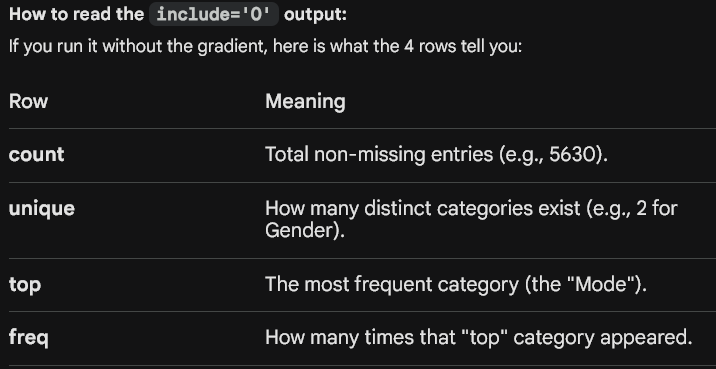

In [11]:
# Show the unique values on each column.
for col in df.columns:
  if df[col].dtype == object:
    print(str(col) + ' : ' + str(df[col].unique()))
    print(df[col].value_counts())
    print("----------------------------------------------------------")

PreferredLoginDevice : ['Mobile Phone' 'Phone' 'Computer']
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
----------------------------------------------------------
PreferredPaymentMode : ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
----------------------------------------------------------
Gender : ['Female' 'Male']
Gender
Male      3384
Female    2246
Name: count, dtype: int64
----------------------------------------------------------
PreferedOrderCat : ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                

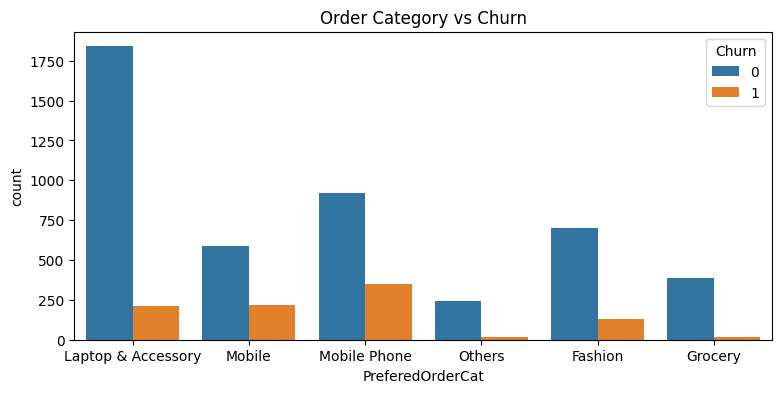

In [12]:
plt.figure(figsize=(9,4))
sns.countplot(data=df, x = 'PreferedOrderCat', hue = 'Churn')
plt.title('Order Category vs Churn')
plt.show()

In [13]:
df.select_dtypes(include=np.number).columns

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [14]:
df.describe().T.style.bar(subset=['mean']).background_gradient(subset=['std','50%','max'])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.000000,52815.500000,1625.385339,50001.000000,51408.250000,52815.500000,54222.750000,55630.000000
Churn,5630.000000,0.168384,0.374240,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure,5366.000000,10.189899,8.557241,0.000000,2.000000,9.000000,16.000000,61.000000
CityTier,5630.000000,1.654707,0.915389,1.000000,1.000000,1.000000,3.000000,3.000000
WarehouseToHome,5379.000000,15.639896,8.531475,5.000000,9.000000,14.000000,20.000000,127.000000
HourSpendOnApp,5375.000000,2.931535,0.721926,0.000000,2.000000,3.000000,3.000000,5.000000
NumberOfDeviceRegistered,5630.000000,3.688988,1.023999,1.000000,3.000000,4.000000,4.000000,6.000000
SatisfactionScore,5630.000000,3.066785,1.380194,1.000000,2.000000,3.000000,4.000000,5.000000
NumberOfAddress,5630.000000,4.214032,2.583586,1.000000,2.000000,3.000000,6.000000,22.000000
Complain,5630.000000,0.284902,0.451408,0.000000,0.000000,0.000000,1.000000,1.000000


In [15]:
# Show the unique values on each column.
for col in df.columns:
  if df[col].dtype == float or df[col].dtype == int:
    print(str(col) + ' : ' + str(df[col].unique()))
    print(df[col].value_counts())
    print("----------------------------------------------------------")

CustomerID : [50001 50002 50003 ... 55628 55629 55630]
CustomerID
55630    1
50001    1
50002    1
50003    1
50004    1
        ..
50019    1
50018    1
50017    1
50016    1
50015    1
Name: count, Length: 5630, dtype: int64
----------------------------------------------------------
Churn : [1 0]
Churn
0    4682
1     948
Name: count, dtype: int64
----------------------------------------------------------
Tenure : [ 4. nan  0. 13. 11.  9. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.
  6. 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51.
 61.]
Tenure
1.0     690
0.0     508
8.0     263
9.0     247
7.0     221
10.0    213
5.0     204
4.0     203
3.0     195
11.0    194
6.0     183
12.0    182
13.0    181
14.0    176
2.0     167
15.0    159
16.0    149
19.0    140
18.0    123
20.0    109
17.0    106
23.0     89
21.0     84
22.0     76
24.0     75
28.0     70
30.0     66
27.0     66
26.0     60
25.0     59
29.0     55
31.0     49
50.0      1
60.0      1
51.0      1
6

In [16]:
# Rough work
df.loc[df['PreferedOrderCat'] == 'Mobile', 'PreferedOrderCat']

,PreferedOrderCat
1,Mobile
2,Mobile
4,Mobile
7,Mobile
8,Mobile
...,...
2803,Mobile
2809,Mobile
3203,Mobile
3417,Mobile


In [17]:
#As mobile phone and phone are both same so we have merged them
df.loc[df['PreferredLoginDevice'] == 'Phone', 'PreferredLoginDevice'] = 'Mobile Phone'
df.loc[df['PreferedOrderCat'] == 'Mobile', 'PreferedOrderCat'] = 'Mobile Phone'

In [18]:
df['PreferredLoginDevice'].value_counts()

,count
PreferredLoginDevice,
Mobile Phone,3996
Computer,1634


In [19]:
df.describe(include='O')

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,2,7,2,5,3
top,Mobile Phone,Debit Card,Male,Mobile Phone,Married
freq,3996,2314,3384,2080,2986


In [20]:
#As mobile phone and phone are both same so we have merged them
df.loc[df['PreferredPaymentMode'] == 'COD', 'PreferredPaymentMode'] = 'Cash on Delivery'
df.loc[df['PreferredPaymentMode'] == 'CC', 'PreferredPaymentMode'] = 'Credit Card'

In [21]:
df['PreferredPaymentMode'].value_counts()

,count
PreferredPaymentMode,
Debit Card,2314
Credit Card,1774
E wallet,614
Cash on Delivery,514
UPI,414


In [22]:
df2 = df.copy()
for col in df2.columns:
  if col == 'CustomerID':
    continue

  else:
    if df2[col].dtype == 'int':
      df2[col] = df[col].astype(str)
df2.dtypes

,0
CustomerID,int64
Churn,object
Tenure,float64
PreferredLoginDevice,object
CityTier,object
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,object


# Churn, CityTeir, NumberofDeviceRegistered, SatisfcationScore, NumberofAddress, Complain
has been converted into Object Type.



In [23]:
df2.describe(include='O')

,Churn,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain
count,5630,5630,5630,5630,5630,5630,5630,5630,5630,5630,5630
unique,2,2,3,5,2,6,5,5,3,15,2
top,0,Mobile Phone,1,Debit Card,Male,4,Mobile Phone,3,Married,2,0
freq,4682,3996,3666,2314,3384,2377,2080,1698,2986,1369,4026


In [24]:
df2.describe().T.style.bar(subset=['mean']).background_gradient(subset=['std','50%','max'])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.000000,52815.500000,1625.385339,50001.000000,51408.250000,52815.500000,54222.750000,55630.000000
Tenure,5366.000000,10.189899,8.557241,0.000000,2.000000,9.000000,16.000000,61.000000
WarehouseToHome,5379.000000,15.639896,8.531475,5.000000,9.000000,14.000000,20.000000,127.000000
HourSpendOnApp,5375.000000,2.931535,0.721926,0.000000,2.000000,3.000000,3.000000,5.000000
OrderAmountHikeFromlastYear,5365.000000,15.707922,3.675485,11.000000,13.000000,15.000000,18.000000,26.000000
CouponUsed,5374.000000,1.751023,1.894621,0.000000,1.000000,1.000000,2.000000,16.000000
OrderCount,5372.000000,3.008004,2.939680,1.000000,1.000000,2.000000,3.000000,16.000000
DaySinceLastOrder,5323.000000,4.543491,3.654433,0.000000,2.000000,3.000000,7.000000,46.000000
CashbackAmount,5630.000000,177.223030,49.207036,0.000000,145.770000,163.280000,196.392500,324.990000


In [25]:
df.duplicated().sum()

np.int64(0)

**Why this is critical:**

As seen in your output, the result is 0. This is excellent news for three reasons:

* **No Bias:** If you had 100 identical rows for a single customer who churned, your Machine Learning model might "over-learn" that specific customer's profile, thinking it's more common than it actually is.

* **Clean Data:** It confirms that each row represents a unique combination of customer data, ensuring your statistics (like the means and counts you calculated earlier) are accurate.

* **Efficiency:** Duplicate data wastes memory and increases training time without adding any new information for the model to learn from.

In [26]:
# the sum of null values
grouped_data = []
for col in columns:
  n_missing = df[col].isnull().sum()
  precentage = n_missing /df.shape[0] * 100
  grouped_data.append([col, n_missing, precentage])

# Create a new DF from grouped_data list
grouped_df = pd.DataFrame(grouped_data, columns=['Column', 'n_missing', 'percenatge'])

# Grouped by 'col', 'n_missing', 'percentage'
result = grouped_df.groupby(['Column', 'n_missing', 'percenatge']).size()
result

,,,0
Column,n_missing,percenatge,
CashbackAmount,0,0.000000,1
Churn,0,0.000000,1
CityTier,0,0.000000,1
Complain,0,0.000000,1
CouponUsed,256,4.547069,1
CustomerID,0,0.000000,1
DaySinceLastOrder,307,5.452931,1
Gender,0,0.000000,1
HourSpendOnApp,255,4.529307,1


In [27]:
from pandas_profiling import ProfileReport
ProfileReport(df, title="Pandas Profiling Report")

Output hidden; open in https://colab.research.google.com to view.

In [28]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

binary_cat_cols = ['Complain']
outcome = ['Churn']
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'NumberOfDeviceRegistered',
            'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain']
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

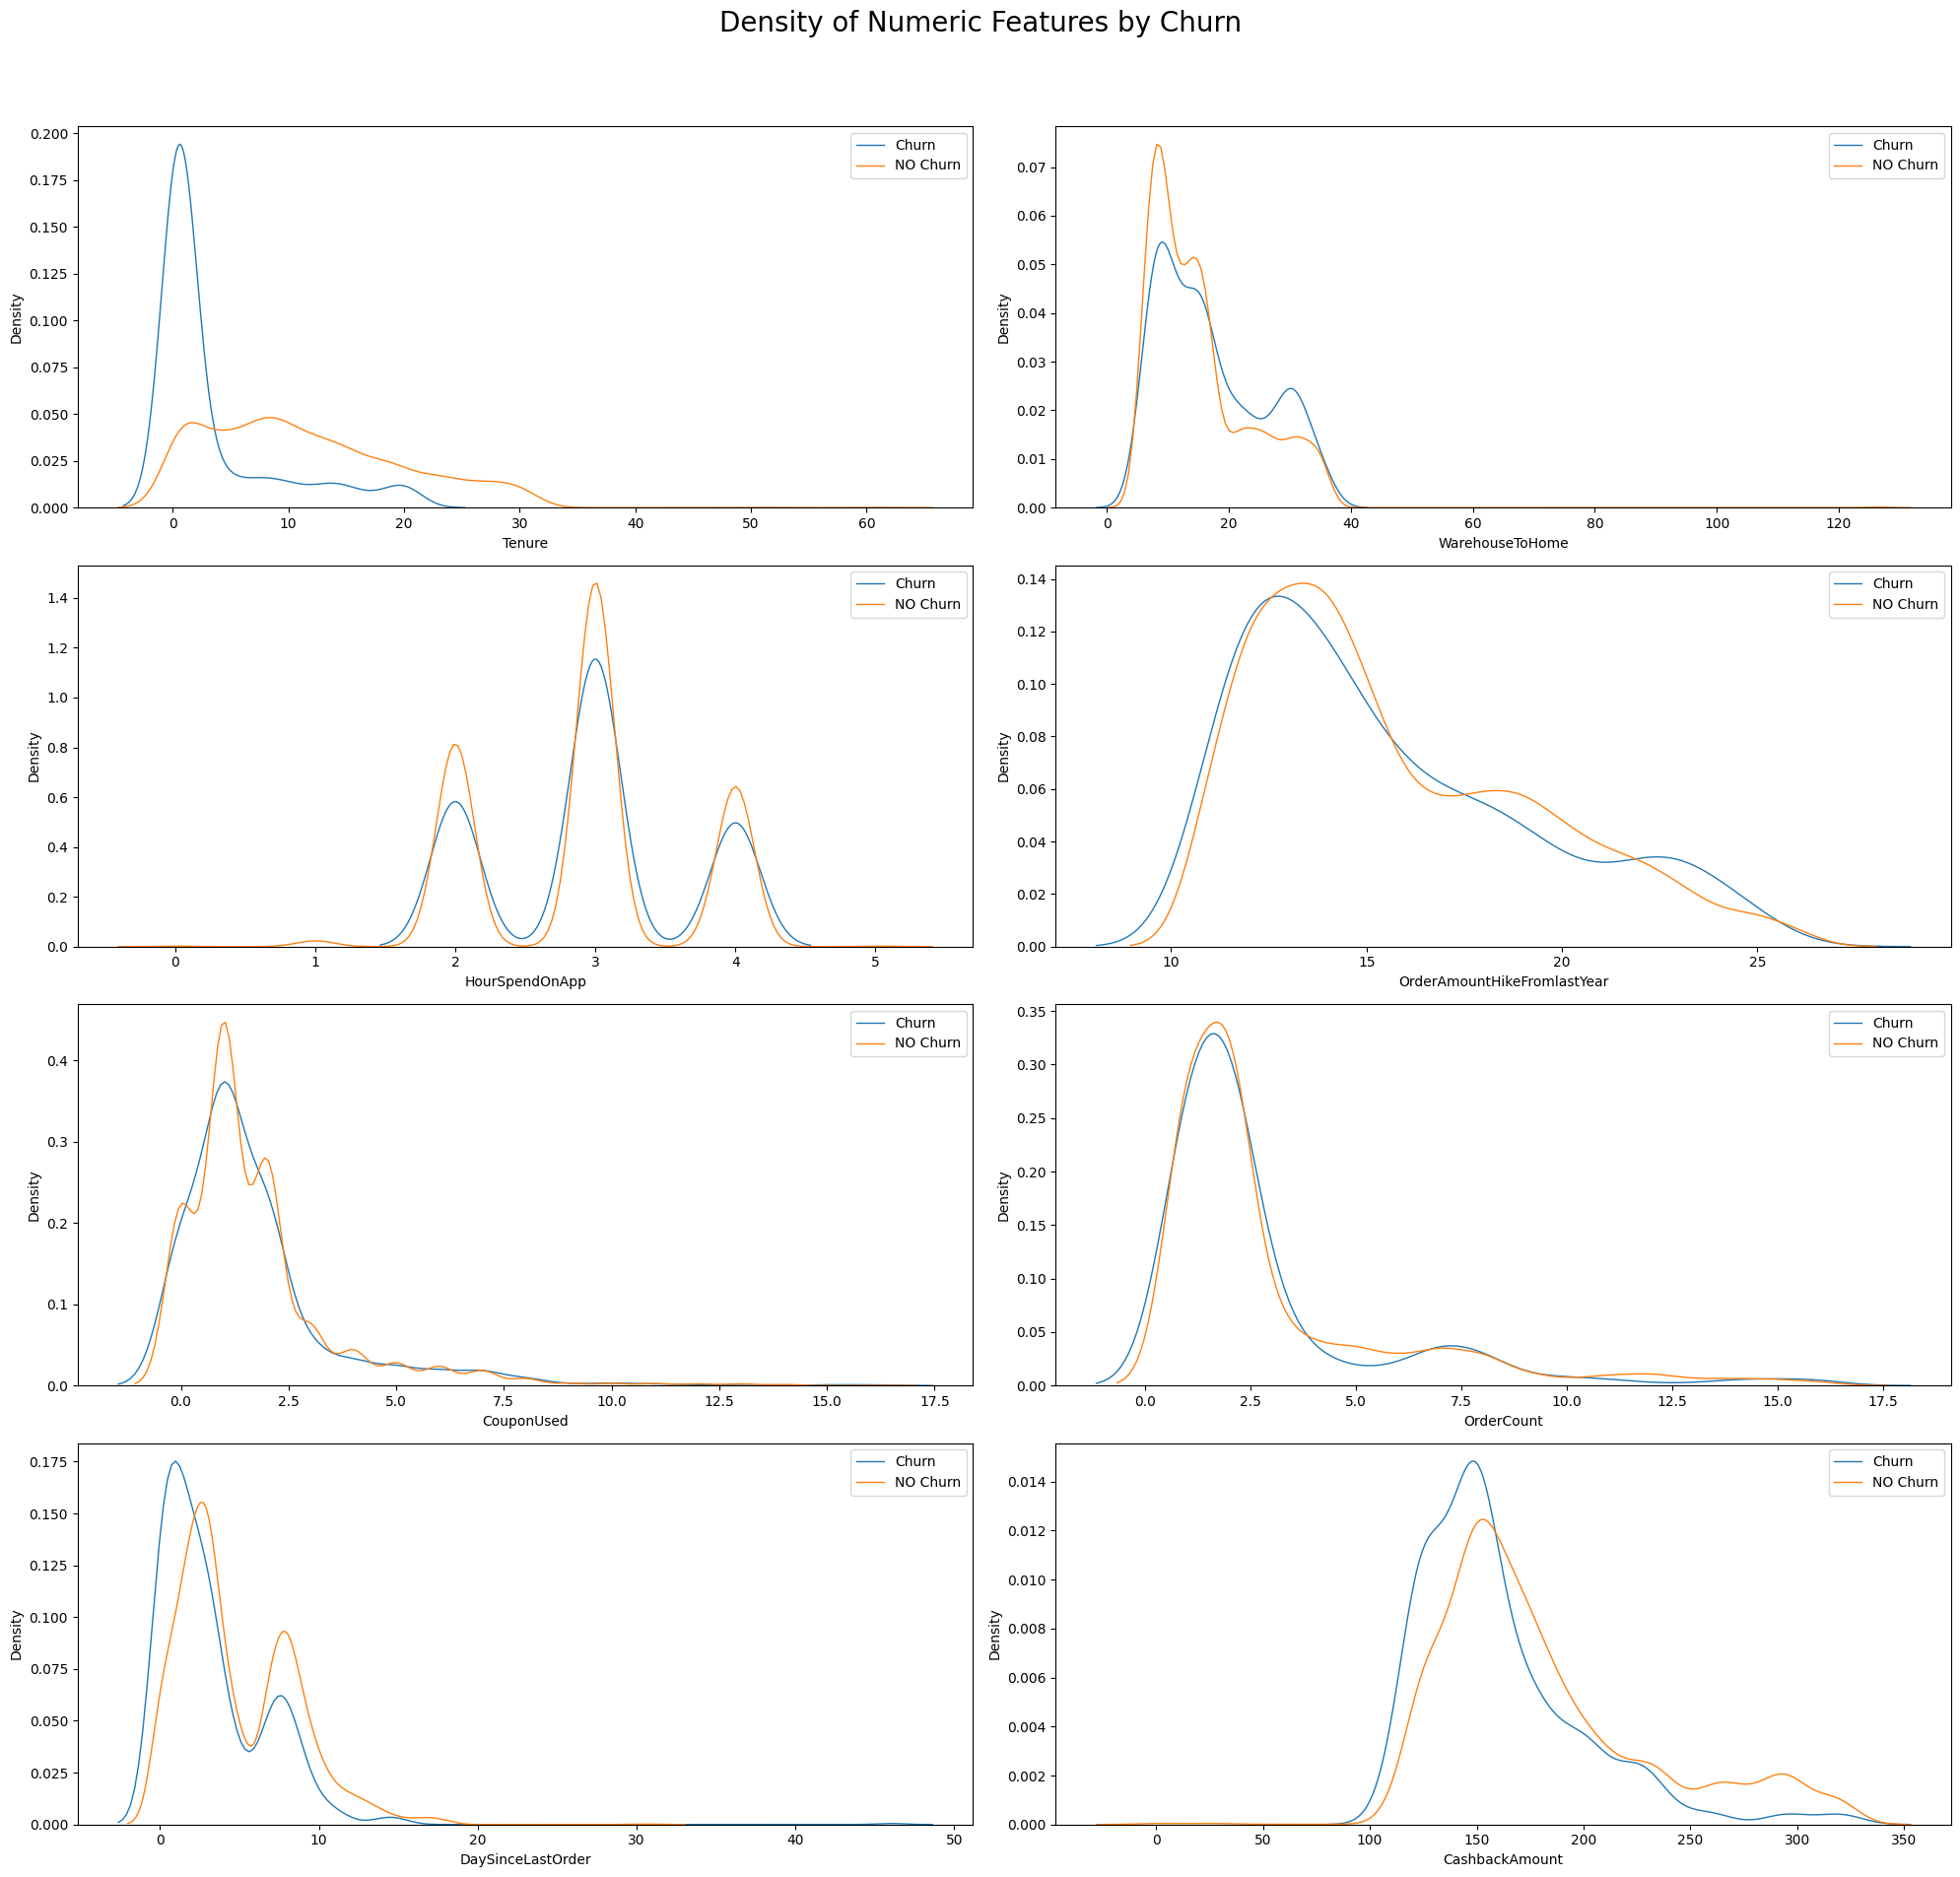

In [29]:
import math

df_c = df[df['Churn'] == 1].copy()
df_nc = df[df['Churn'] == 0].copy()

# Dynamic Grid Calculation
# The code calculates how many rows (nrows) it needs based on the number of features in your num_cols list,
# assuming 3 columns (ncols) per row.
# This ensures the grid scales if you add or remove features.
num_plots = len(num_cols)
ncols = 2 # You can adjust the number of columns
nrows = math.ceil(num_plots / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize = (20, 5 * nrows)) # Adjusted figsize dynamically
fig.suptitle('Density of Numeric Features by Churn', fontsize=20)
ax = ax.flatten()

for idx,c in enumerate(num_cols):
   sns.kdeplot(df_c[c], linewidth= 1,
             label = 'Churn',ax=ax[idx])
   sns.kdeplot(df_nc[c], linewidth= 1,
             label = 'NO Churn',ax=ax[idx])
   ax[idx].legend(loc='upper right')

# Hide any unused subplots
for i in range(num_plots, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

**Context from the Visualization:**

These plots are used to find "Separation." If the two curves (Churn vs. No Churn) look different, that feature is a strong predictor of churn.

Based on your current KDE output:

* **Tenure,** you will see a massive peak for Churners at low values. This confirms that new customers are highly unstable.

* **DaySinceLastOrder:** Notice the "Churn" curve (blue) is taller at the very low end (near 0-1 days). This is interesting—it might suggest that some customers place a final order and then immediately leave, or that frequent recent activity doesn't always guarantee loyalty.

* **CashbackAmount:** You'll notice the "No Churn" curve (orange) is slightly shifted toward the right (higher values). This indicates that customers receiving higher cashback are more likely to stay. Cashback acts as a "glue" for retention.

In future Machine Learning steps, these density plots justify Feature Selection.

Features where the curves are almost identical (overlapping perfectly) are "noisy" and don't help the model much.

Features where the curves are distinct (like Tenure and CashbackAmount) are your "Gold Nuggets"—they will be the primary reasons your model succeeds in predicting who will leave.

# 1. Is there a relationship between Gender and Churn? & Which Gender has more Orders?


Some reference work of crosstab

a = {

    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],

    'Product': ['A', 'B', 'A', 'A', 'C', 'B']
}

df = pd.DataFrame(a)

**Generate crosstab**

```
# res = pd.crosstab(df['Gender'], df['Product'])

print(res)
```



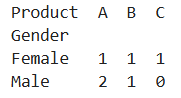

In [30]:
# Churn by Gender
gender_churn = pd.crosstab(df['Gender'], df['Churn'], normalize='index')
gender_churn

Churn,0,1
Gender,,
Female,0.845058,0.154942
Male,0.822695,0.177305


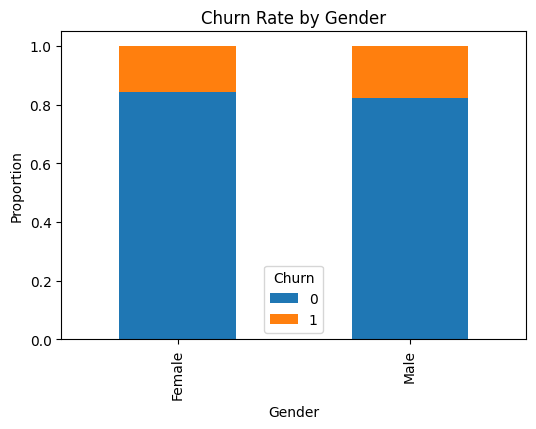

In [31]:
gender_churn.plot(kind='bar',stacked=True, figsize=(6,4))
plt.title('Churn Rate by Gender')
plt.ylabel("Proportion")
plt.show()

**Conclusion:**

```
Males are slightly more likely to churn than females (by about 2.2%).
While this is a measurable difference, it is not a "strong" predictor compared to other features like Complain or Tenure.
Your machine learning model will consider Gender, but it won't be the deciding factor.
```

-----

In [32]:
df.groupby('Gender')['OrderCount'].mean()

,OrderCount
Gender,
Female,3.122459
Male,2.933681


In [33]:
df.groupby('Gender')['OrderCount'].agg(['sum', 'count','mean'])

,sum,count,mean
Gender,,,
Female,6604.0,2115,3.122459
Male,9555.0,3257,2.933681


* **Total Orders (Sum):** Males have significantly more orders (9,555 vs 6,604). This is simply because there are more male customers in your dataset (3,384 males vs 2,246 females).

* **Average Orders (Mean):** Females place more orders on an individual basis (3.12 vs 2.93).

-----

In [34]:
fig = px.pie(df, values='Churn', names='Gender')
fig.update_traces(marker=dict(colors=['tomato', 'cornflowerblue']))
fig.update_layout(title='Churn Rate by Gender', legend_title = 'Gender')
fig.show()

# 2. Which MaritalStatus has the highest Churn rate?

In [35]:
marital_churn = df.groupby("MaritalStatus")['Churn']\
  .value_counts()

marital_churn

MaritalStatus  Churn
Divorced       0         724
               1         124
Married        0        2642
               1         344
Single         0        1316
               1         480
Name: count, dtype: int64

In [36]:
# More Simplified way
marital_churn = df.groupby("MaritalStatus")['Churn'].value_counts(normalize=True).unstack()
marital_churn

Churn,0,1
MaritalStatus,,
Divorced,0.853774,0.146226
Married,0.884796,0.115204
Single,0.732739,0.267261


In [37]:
marital_churn = df.groupby("MaritalStatus")['Churn']\
                  .value_counts(normalize=True)\
                  .unstack()
marital_churn

Churn,0,1
MaritalStatus,,
Divorced,0.853774,0.146226
Married,0.884796,0.115204
Single,0.732739,0.267261


In [38]:
marital_churn = pd.crosstab(df['MaritalStatus'], df['Churn'], normalize='index')
marital_churn

Churn,0,1
MaritalStatus,,
Divorced,0.853774,0.146226
Married,0.884796,0.115204
Single,0.732739,0.267261


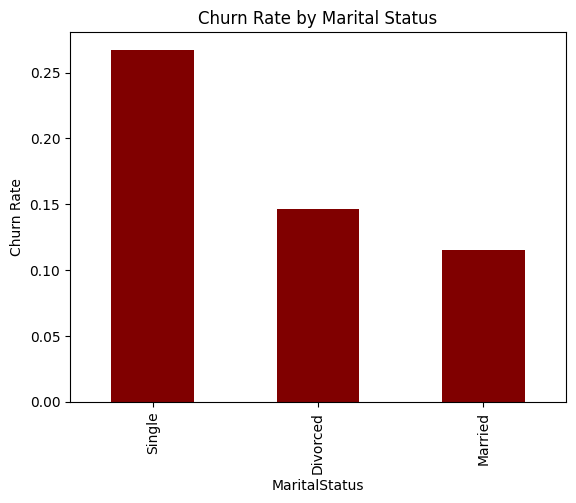

In [39]:
marital_churn[1].sort_values(ascending=False).plot(kind='bar', color='maroon')
plt.title('Churn Rate by Marital Status')
plt.ylabel("Churn Rate")
plt.show()

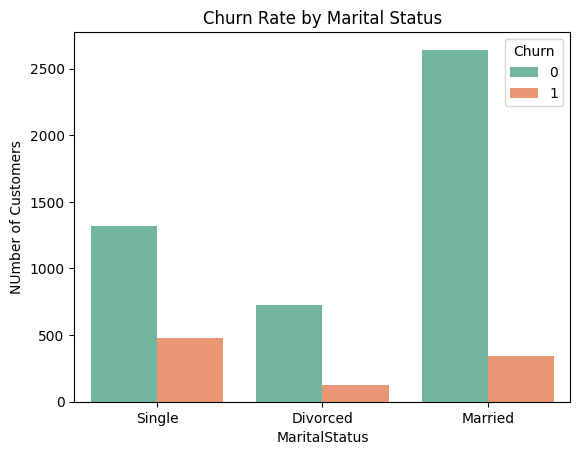

In [40]:
sns.countplot(x='MaritalStatus', hue='Churn', data=df, palette='Set2')
plt.title('Churn Rate by Marital Status')
plt.ylabel("NUmber of Customers")
plt.show()

**The Conclusion**

Single customers have the highest churn rate by a significant margin.

The married are the highest customer segment in the company may be the company should consider taking care of the products that suits the singles.

**Why this matters for your Project:**

* **Targeting:** From a business perspective, the "Single" segment is your biggest "leak." Any retention budget should be prioritized here.

* **Feature Importance:** In Machine Learning model, MaritalStatus will be a critical predictor. If the model sees a "Single" customer, it will automatically increase the probability score for Churn.

* **The "Why":** This often correlates with Tenure. Single users are frequently newer to the platform and haven't built the same "habit" or loyalty as married users.



In [41]:
# Calculate average tenure for each marital status
tenure_analysis = df.groupby('MaritalStatus')['Tenure'].mean().sort_values()
tenure_analysis

,Tenure
MaritalStatus,
Single,8.662154
Married,10.867297
Divorced,11.004932


# 3. Which CityTier has higher Tenure and OrderCount?

In [42]:
df.groupby('CityTier')[['Tenure','OrderCount']].mean()

,Tenure,OrderCount
CityTier,,
1,10.528818,2.953255
2,11.169725,2.584034
3,9.361740,3.185185


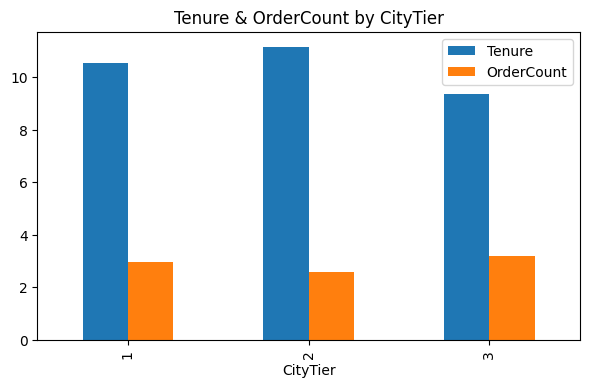

In [43]:
df.groupby('CityTier')[['Tenure','OrderCount']].mean().plot(kind='bar',figsize=(7,4))
plt.title('Tenure & OrderCount by CityTier')
plt.show()

# 4. Do customers with high SatisfactionScore spend more time on the app?

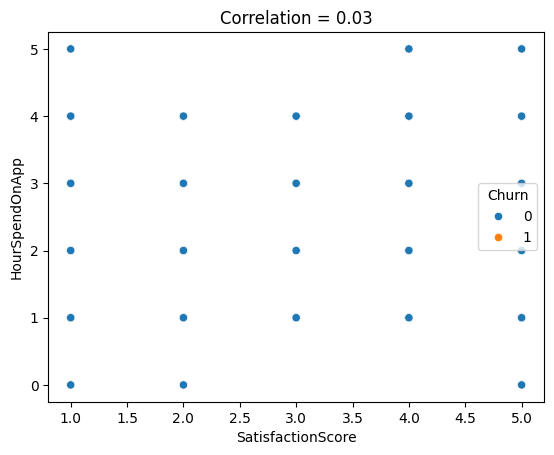

In [44]:
corr = df['SatisfactionScore'].corr(df['HourSpendOnApp'])
sns.scatterplot(data=df,
                x='SatisfactionScore',
                y='HourSpendOnApp',
                hue='Churn')
plt.title(f"Correlation = {corr:.2f}")
plt.show()

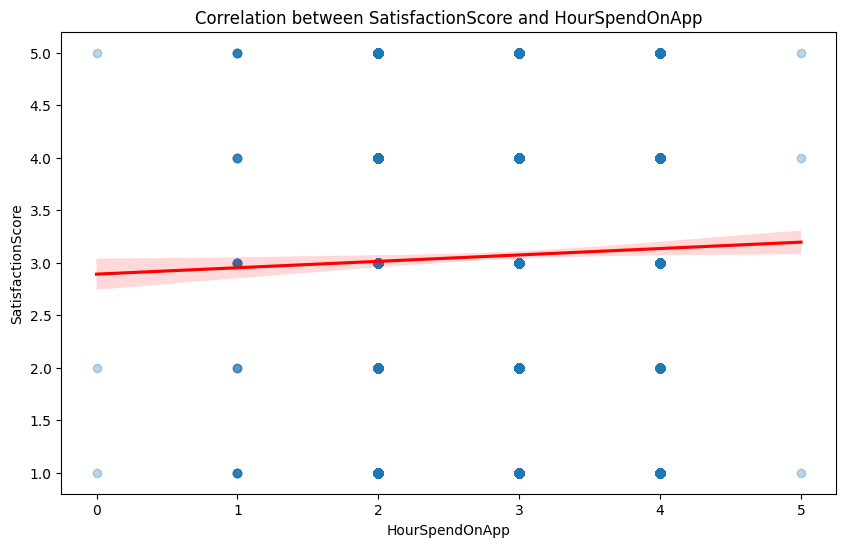

In [45]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='HourSpendOnApp', y ='SatisfactionScore', scatter_kws={'alpha':0.3},
            line_kws={'color':'red'})
plt.title('Correlation between SatisfactionScore and HourSpendOnApp')
plt.show()

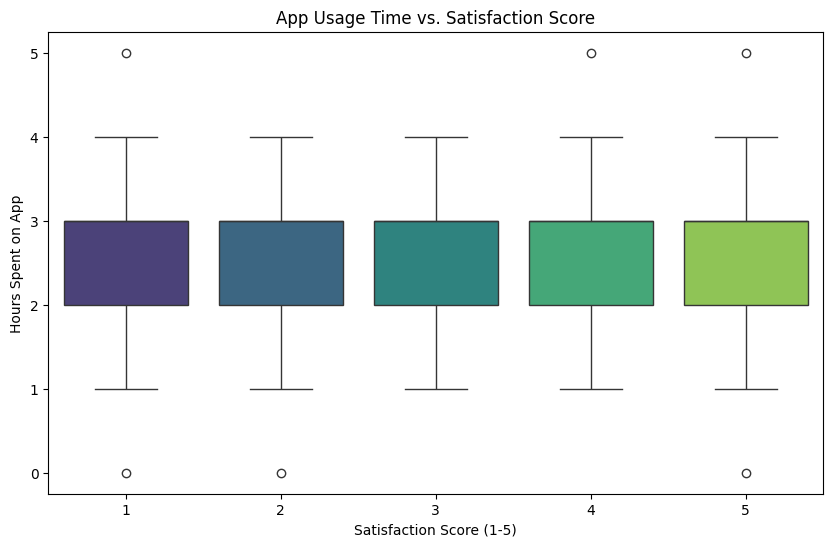

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='SatisfactionScore', y='HourSpendOnApp', data=df, palette='viridis')

plt.title('App Usage Time vs. Satisfaction Score')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Hours Spent on App')
plt.show()

**Conclusion & Business Insight**

To draw a conclusion, look at the "Median" lines across the five boxes:

**Scenario A:** The boxes get higher as the score increases.

* **Conclusion:** There is a Positive Correlation. Higher satisfaction leads to higher engagement. These users are likely "browsing for fun" and are loyal.

**Scenario B:** The boxes are all roughly at the same height (Most likely for this dataset).

* **Conclusion:** Satisfaction Score is not a driver of App Usage Time. This suggests that "Time on App" is dictated by the need to buy something, rather than how happy the customer is. A customer who hates the app (Score 1) might still spend 3 hours on it because they are trying to resolve an issue.

**Scenario C:** Score 1 and Score 5 both have high usage.

* **Conclusion:** You have two types of high-usage users: The "Frustrated" (Score 1 - struggling with the app) and the "Fans" (Score 5 - love browsing).


**Final Takeaway from this Project:**
If you find that the boxes are mostly level, it tells your Machine Learning model that HourSpendOnApp is not a good proxy for satisfaction. You cannot assume a user is happy just because they are spending a lot of time on the app.

# 5. Is there a correlation between SatisfactionScore & HourSpendOnApp?

In [47]:
df['SatisfactionScore'].corr(df['HourSpendOnApp'])

np.float64(0.0318580058110035)

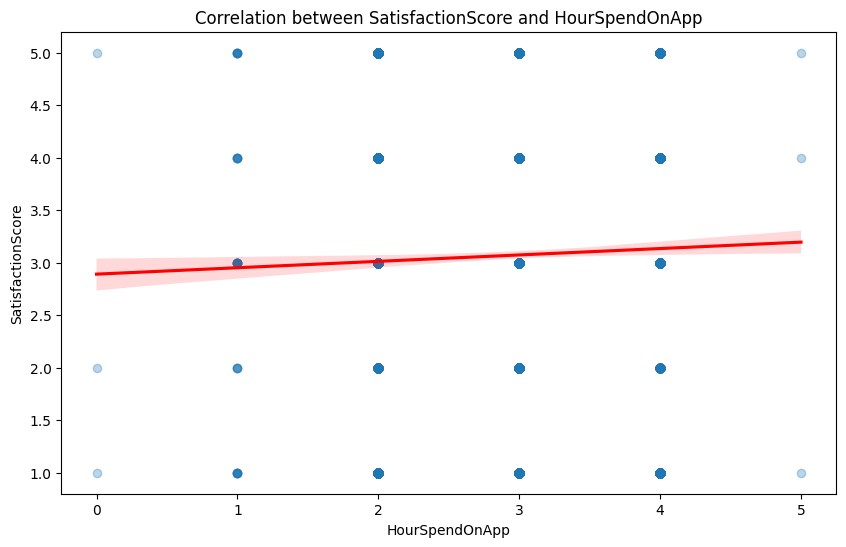

In [48]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='HourSpendOnApp', y ='SatisfactionScore', scatter_kws={'alpha':0.3},
            line_kws={'color':'red'})
plt.title('Correlation between SatisfactionScore and HourSpendOnApp')
plt.show()

# 6. Which CityTier has the most HourSpendOnApp?

In [49]:
df.groupby('CityTier')['HourSpendOnApp'].mean()

,HourSpendOnApp
CityTier,
1,2.937913
2,2.878924
3,2.925284


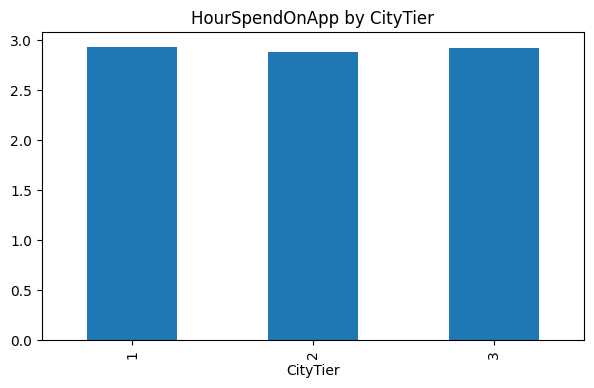

In [50]:
df.groupby('CityTier')['HourSpendOnApp'].mean().plot(kind='bar',figsize=(7,4))
plt.title('HourSpendOnApp by CityTier')
plt.show()

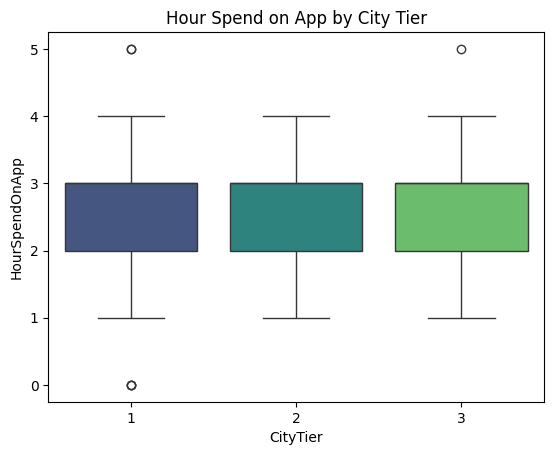

In [51]:
sns.boxplot(data=df,x='CityTier', y='HourSpendOnApp',palette='viridis')
plt.title('Hour Spend on App by City Tier')
plt.show()

In [52]:
df.groupby('CityTier')['HourSpendOnApp'].sum()

,HourSpendOnApp
CityTier,
1,10221.0
2,642.0
3,4894.0


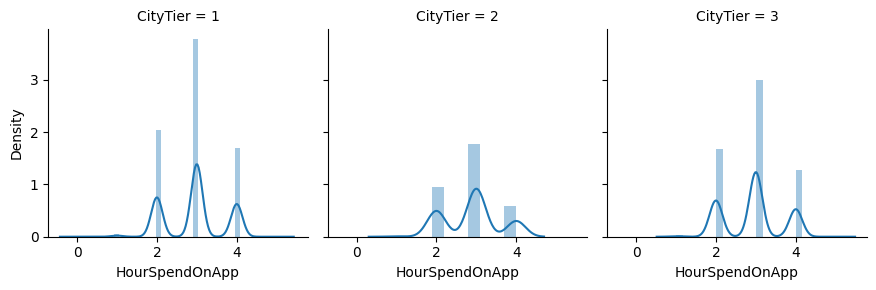

,HourSpendOnApp
CityTier,
1,10221.0
2,642.0
3,4894.0


In [53]:
g=sns.FacetGrid(df,col='CityTier')
g.map(sns.distplot,'HourSpendOnApp')
plt.show()

df.groupby('CityTier')['HourSpendOnApp'].sum()

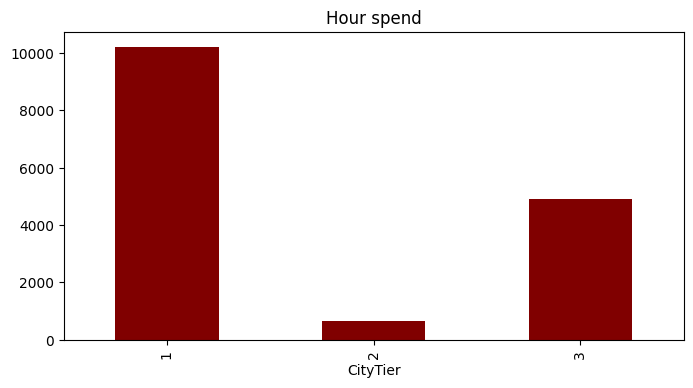

In [54]:
df.groupby('CityTier')['HourSpendOnApp'].sum().plot(kind='bar',figsize=(8,4),color='maroon')
plt.title('Hour spend')
plt.show()

**City Tier 1 has the most spended hours on the app**

**The Observation:**

The peaks for all three City Tiers are concentrated around 2, 3, and 4 hours. The "shape" of the usage does not drastically change whether the user is in a highly developed Tier 1 city or a Tier 3 city.



**The Conclusion:**

City Tier does not influence App Usage Time. From a business perspective, this means your app engagement is "Tier-agnostic." You don't need different engagement strategies for different cities because everyone—regardless of location—spends roughly the same amount of time browsing.

# 7. Relation between NumberOfAddress and CityTier within churn segment

In [55]:
df.groupby('CityTier')['NumberOfAddress'].value_counts()

CityTier  NumberOfAddress
1         2                  871
          3                  832
          4                  397
          5                  377
          6                  247
          1                  228
          8                  187
          7                  173
          9                  150
          10                 129
          11                  71
          19                   1
          20                   1
          21                   1
          22                   1
2         2                   61
          3                   43
          5                   30
          1                   23
          6                   21
          4                   16
          10                  13
          7                   10
          8                   10
          11                   9
          9                    6
3         2                  437
          3                  403
          4                  175
          5                  164
          1                  120
          6                  114
          8                   83
          9                   83
          7                   73
          10                  52
          11                  18
Name: count, dtype: int64

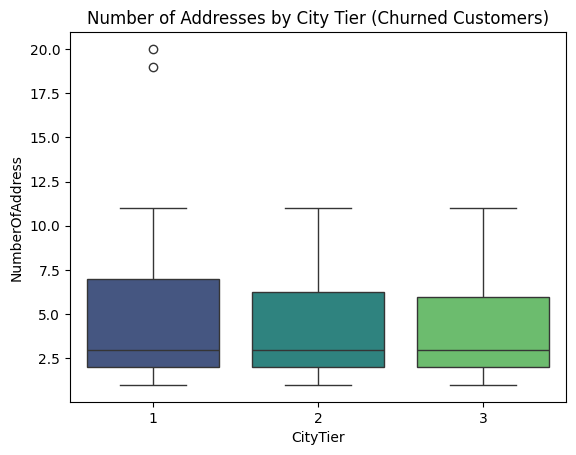

In [56]:
churn_df=df[df['Churn']==1]
sns.boxplot(data=churn_df,x='CityTier', y='NumberOfAddress',palette='viridis')

plt.title("Number of Addresses by City Tier (Churned Customers)")
plt.show()


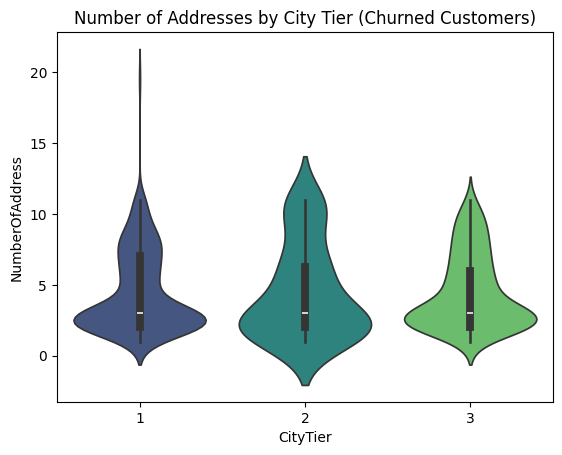

-------------------------------
Value of Correlation between CityTier & NumberOfAddress:
Correlation: -0.03


In [57]:
sns.violinplot(data=churn_df,x='CityTier', y='NumberOfAddress',palette='viridis')
plt.title("Number of Addresses by City Tier (Churned Customers)")
plt.show()

print('-------------------------------')
corr=df['CityTier'].corr(df['NumberOfAddress'])
print('Value of Correlation between CityTier & NumberOfAddress:')
print(f'Correlation: {corr:.2f}')

**Detailed Interpretation of the Shapes-**

* **The "Bulge" (Width):** In all three City Tiers, the violins are widest between 2 and 5 addresses. This tells you that the "typical" churner isn't someone with just one home address; they are usually managing multiple locations.

* **The "Neck" (Top):** You see a thin line stretching all the way up to 20+ addresses. These are your outliers—power users who moved or shipped to many locations but still ended up leaving.

* **The Inner White Dot:** This is the median. If you notice the white dot is roughly at the same height (around 4) for all tiers, it proves that City Tier doesn't change this behavior.


**Final Conclusion & Insight**

The consistency of these shapes across Tiers 1, 2, and 3 leads to a significant discovery of this project:

**Conclusion:**

The "Number of Addresses" is a universal churn indicator. Whether a customer is in a Tier 1 or Tier 3 city, once they accumulate more than 4-5 addresses, they enter a "High Risk" zone for churning.

**The Business Logic:**

This complexity might suggest these users are more difficult to satisfy because they have varied delivery needs across multiple locations. If the e-commerce platform fails to handle one of those many addresses correctly, the user is likely to leave the entire platform.

# 8. What is the relation between Complain and DaySinceLastOrder?

In [58]:
df[['DaySinceLastOrder','Complain']].corr()

,DaySinceLastOrder,Complain
DaySinceLastOrder,1.000000,-0.043546
Complain,-0.043546,1.000000


In [59]:
df['DaySinceLastOrder'].corr(df['Complain'])

np.float64(-0.04354625080419038)

In [60]:
df.groupby('Complain')['DaySinceLastOrder'].mean()

,DaySinceLastOrder
Complain,
0,4.644135
1,4.291913


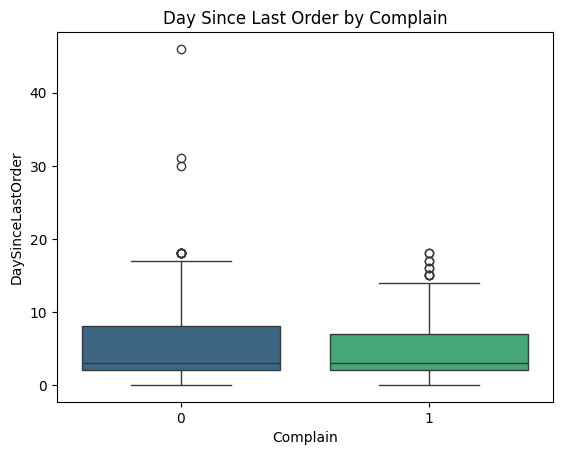

In [61]:
sns.boxplot(data=df,x='Complain',y='DaySinceLastOrder',palette='viridis')
plt.title('Day Since Last Order by Complain')
plt.show()

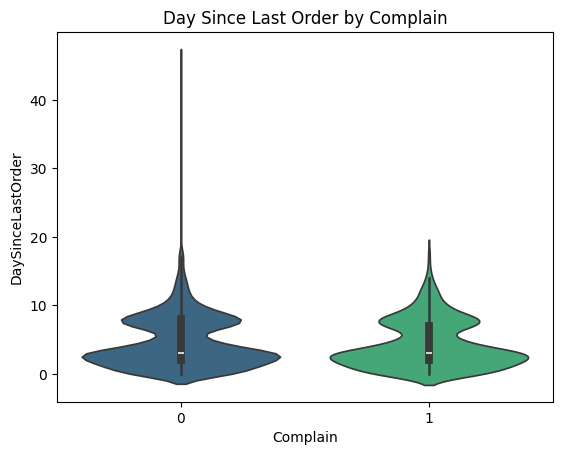

In [62]:
sns.violinplot(data=df,x='Complain',y='DaySinceLastOrder',palette='viridis')
plt.title('Day Since Last Order by Complain')
plt.show()

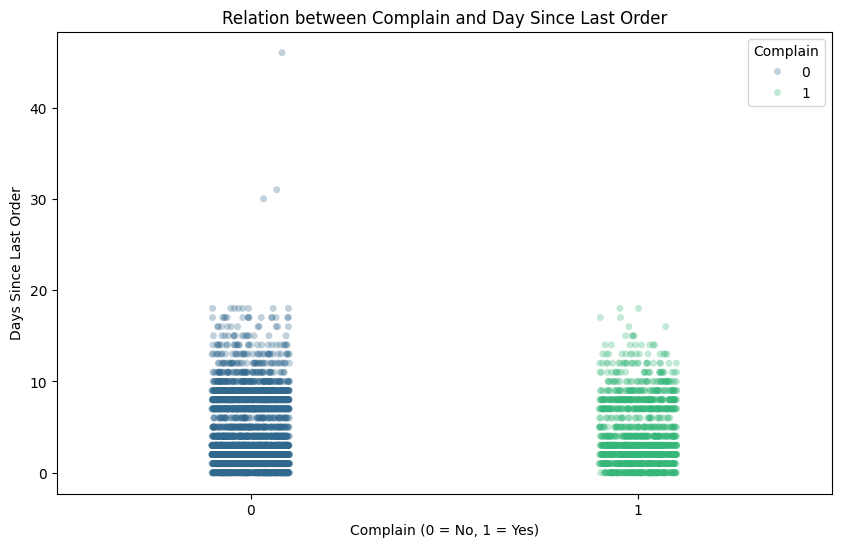

In [63]:
plt.figure(figsize=(10, 6))
# Using stripplot which is a scatterplot for categorical x-axis
sns.stripplot(data=df, x='Complain', y='DaySinceLastOrder', jitter=True, alpha=0.3, palette='viridis',hue='Complain')

plt.title('Relation between Complain and Day Since Last Order')
plt.xlabel('Complain (0 = No, 1 = Yes)')
plt.ylabel('Days Since Last Order')
plt.show()

In [64]:
fig = px.strip(df,
               x='Complain',
               y='DaySinceLastOrder',
               color='Complain',
               title='Interactive: Complain vs Day Since Last Order',
               hover_data=['CustomerID', 'SatisfactionScore', 'Tenure'], # Add extra info on hover
               stripmode='overlay')

# This enables the hovermode you asked for
fig.update_layout(hovermode='closest')

fig.show()

In [65]:
import plotly.express as px
# Create a density heatmap with marginal distributions
fig = px.density_heatmap(df,
                         x='Complain',
                         y='DaySinceLastOrder',
                         marginal_x="histogram", # Shows total count of complaints at the top
                         marginal_y="histogram", # Shows total distribution of days on the side
                         title='Density Heatmap: Concentration of Complaints vs Recency',
                         labels={'Complain': 'Complaint (0=No, 1=Yes)', 'DaySinceLastOrder': 'Days Since Last Order'})

# Refine layout
fig.update_layout(height=900, hovermode='closest')

fig.show()

**Observation:**

Most orders (whether there was a complaint or not) happen within 0–10 days.

**Relationship:**

The density pattern for Complain=1 is almost an identical "shrunken" version of Complain=0.

**Insight:**

This confirms that complaints are not causing a unique delay in ordering. If they were, you would see a "gap" in the yellow heat zones for the Complain=1 column, but the heat is distributed similarly.


> **There is a weak negative relation between complainig and the number of dayes since last order**



# 9. Relationship between PreferredLoginDevice and Churn

In [66]:
login_churn = pd.crosstab(df['PreferredLoginDevice'],df['Churn'], normalize='index')
login_churn

Churn,0,1
PreferredLoginDevice,,
Computer,0.801714,0.198286
Mobile Phone,0.843844,0.156156


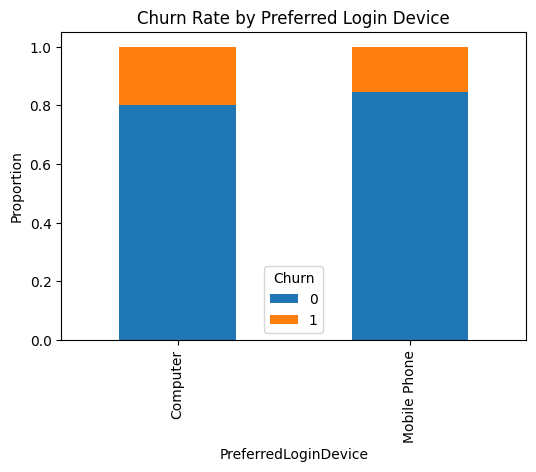

In [67]:
login_churn.plot(kind='bar',stacked=True,figsize=(6,4))
plt.title('Churn Rate by Preferred Login Device')
plt.ylabel("Proportion")
plt.show()

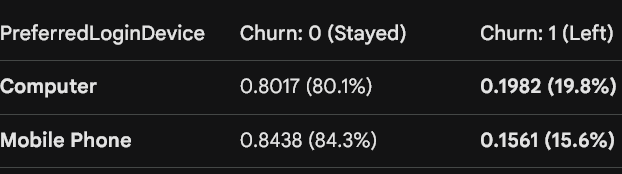

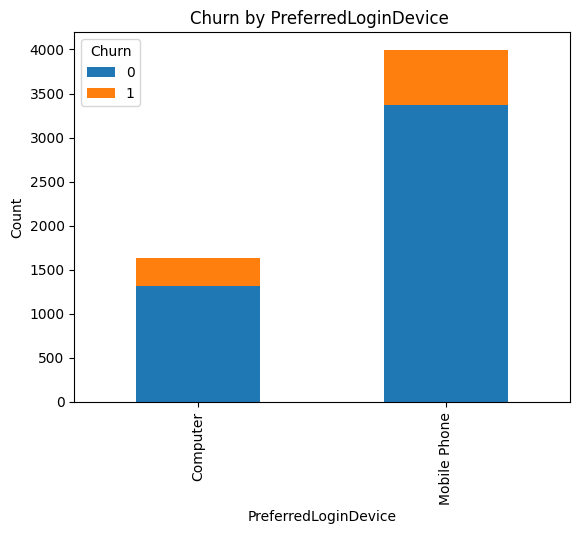

In [68]:
# Group the data by 'OverTime' and 'Attrition', and calculate the count
grouped_data = df.groupby(['PreferredLoginDevice', 'Churn']).size().unstack().plot(kind='bar', stacked=True)

# Set the plot title, x-label, and y-label
plt.title('Churn by PreferredLoginDevice ')
plt.xlabel('PreferredLoginDevice')
plt.ylabel('Count')

# Show the plot
plt.show()

Data as your previous crosstab, it provides a different business perspective because **it visualizes Volume (Count) rather than Probability (Rate).**

* **The Key Difference:** Count vs. Percentage
The Crosstab Approach (normalize='index'): Showed you that Computer users have a higher likelihood of leaving (~20% vs ~15%).

* **This Bar Plot Approach**(.size()):
Shows you that Mobile Phone users make up the largest total number of churners.

# 10. Distance from Warehouse to Home across City Tiers

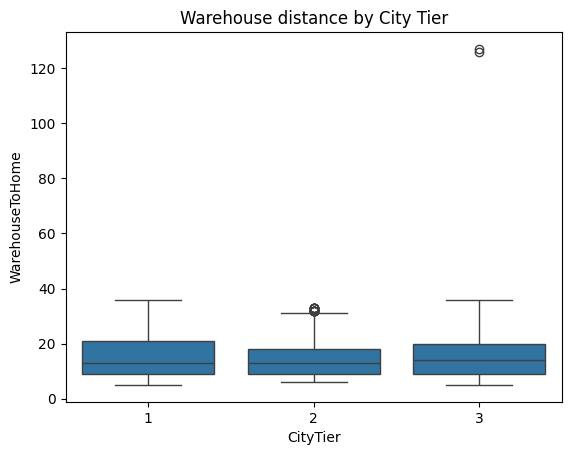

In [69]:
sns.boxplot(data=df,x='CityTier', y='WarehouseToHome')
plt.title('Warehouse distance by City Tier')
plt.show()

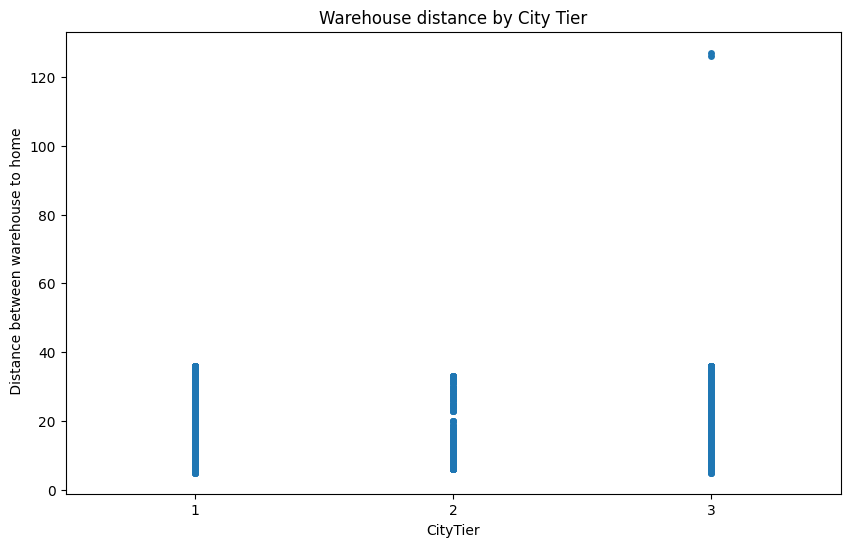

In [70]:
df3=df.copy()

df3['CityTier'].astype('str')
plt.figure(figsize=(10,6))
sns.stripplot(data=df3,x='CityTier',y='WarehouseToHome',jitter=False)
plt.ylabel(' Distance between warehouse to home')
plt.title('Warehouse distance by City Tier')
plt.show()

**The Bulk:** For all three tiers, the dots are incredibly dense between 5 and 40 units. This is your "Standard Delivery Zone."

**The Outlier:** Notice that one lone dot way up at 120+ units in Tier 3? That is an extreme outlier—a customer living very far from the warehouse.

**The Overlap:** Because the three pillars look almost identical in height and density, it suggests that the "Warehouse to Home" distance is actually standardized across the company's network.



# 11. Do different CityTiers prefer different product categories?

In [71]:
pd.crosstab(df['CityTier'], df['PreferedOrderCat'], normalize='index')

PreferedOrderCat,Fashion,Grocery,Laptop & Accessory,Mobile Phone,Others
CityTier,,,,,
1,0.132570,0.072559,0.292962,0.450627,0.051282
2,0.099174,0.057851,0.198347,0.537190,0.107438
3,0.183508,0.075494,0.538908,0.173055,0.029036


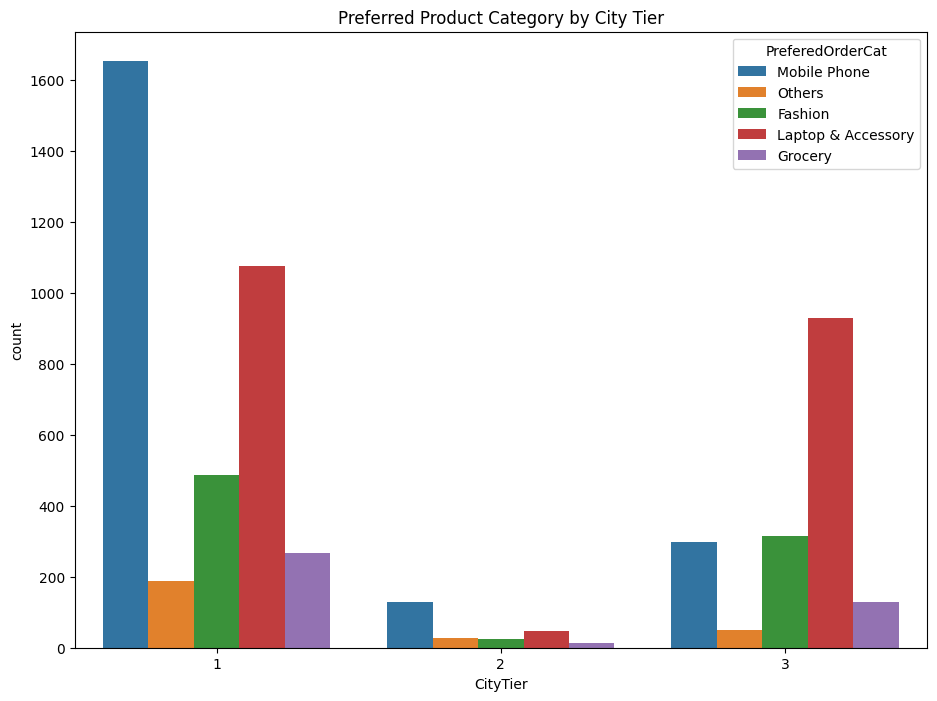

In [72]:
plt.figure(figsize=(11,8))
sns.countplot(data=df, x='CityTier',hue='PreferedOrderCat')
plt.title('Preferred Product Category by City Tier')
plt.show()

In [73]:
from plotly.graph_objs import YAxis
fig = px.histogram(df,
                   x='CityTier',
                   color='PreferedOrderCat',
                   barmode='group',
                   hover_data=['PreferedOrderCat'], # Add extra info to hover
                   title='Interactive Churn Count by City Tier')

fig.show()

# 12. What is the preferred payment mode for different CityTiers?

In [74]:
df2['PreferredPaymentMode'].value_counts()

,count
PreferredPaymentMode,
Debit Card,2314
Credit Card,1774
E wallet,614
Cash on Delivery,514
UPI,414


In [75]:
df2.groupby('CityTier')['PreferredPaymentMode'].value_counts()

CityTier  PreferredPaymentMode
1         Debit Card              1676
          Credit Card             1382
          Cash on Delivery         366
          UPI                      242
2         UPI                      114
          Debit Card                62
          Credit Card               50
          Cash on Delivery          16
3         E wallet                 614
          Debit Card               576
          Credit Card              342
          Cash on Delivery         132
          UPI                       58
Name: count, dtype: int64

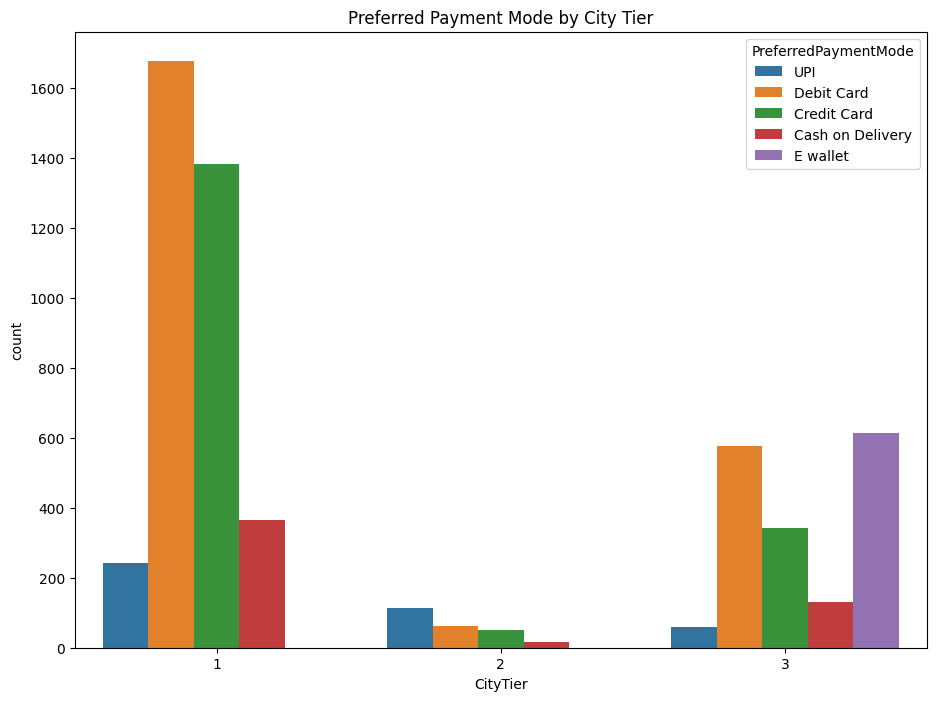

In [76]:
plt.figure(figsize=(11,8))
sns.countplot(data=df, x='CityTier', hue='PreferredPaymentMode')
plt.title('Preferred Payment Mode by City Tier')
plt.show()

In [77]:
fig=px.histogram(
    df,
    x='CityTier',
    color='PreferredPaymentMode',
    barmode='group',
    hover_data=['PreferredPaymentMode'],
    title='Interactive Churn Count by City Tier'
)
fig.show()

<Axes: xlabel='CityTier'>

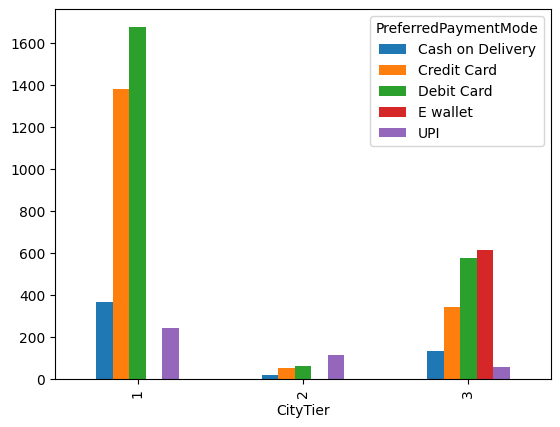

In [78]:
df2.groupby('CityTier')['PreferredPaymentMode'].value_counts().unstack().plot(kind='bar', stacked=False)

# 13. Which CityTier has the highest OrderCount?

In [79]:
df.groupby('CityTier')['OrderCount'].sum()

,OrderCount
CityTier,
1,10298.0
2,615.0
3,5246.0


<Axes: title={'center': 'City Tier vs Order Count'}, xlabel='CityTier'>

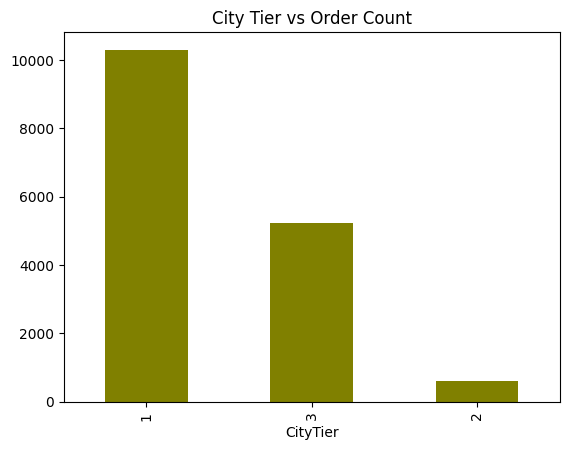

In [80]:
df.groupby('CityTier')['OrderCount'].sum()\
.sort_values(ascending=False).plot(kind='bar', color='olive', title='City Tier vs Order Count', y='OrderCount')

In [81]:
fig = px.histogram(df2, x="OrderCount", y="CityTier",
                   orientation="h", color="CityTier" ,text_auto= True ,
                   title="<b>"+'CityTier Vs Sum of OrderCount' ,
                   color_discrete_sequence = ['#BA1F33','#3A506B','#3E885B'])

# Customize the plot
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(title_font_color="black",
                  template="plotly",
                  title_font_size=30,
                  hoverlabel_font_size=15,
                  title_x=0.5,
                  xaxis_title='Sum of OrderCount',
                  yaxis_title='City Tier',
                  yaxis={'categoryorder':'total ascending'})

fig.show()

CityTier '1' has highest order count with 10298 **orders**

# 14. Does increase in order amount from last year affect churn?

In [82]:
df2['OrderAmountHikeFromlastYear'].value_counts()

,count
OrderAmountHikeFromlastYear,
14.0,750
13.0,741
12.0,728
15.0,542
11.0,391
16.0,333
18.0,321
19.0,311
17.0,297


In [83]:
df2.groupby('Churn')['OrderAmountHikeFromlastYear'].value_counts()

Churn  OrderAmountHikeFromlastYear
0      14.0                           634
       13.0                           613
       12.0                           584
       15.0                           460
       11.0                           309
       16.0                           269
       18.0                           267
       19.0                           267
       17.0                           243
       20.0                           211
       21.0                           166
       22.0                           150
       23.0                           108
       24.0                            60
       25.0                            59
       26.0                            31
1      12.0                           144
       13.0                           128
       14.0                           116
       11.0                            82
       15.0                            82
       16.0                            64
       17.0                            54
       18.0                            54
       19.0                            44
       23.0                            36
       22.0                            34
       20.0                            32
       21.0                            24
       24.0                            24
       25.0                            14
       26.0                             2
Name: count, dtype: int64

In [84]:
hike_analysis = df.groupby('OrderAmountHikeFromlastYear')['Churn'].mean().reset_index()
hike_analysis['Churn Rate (%)'] = hike_analysis['Churn'] * 100

hike_analysis

# fig = px.bar(hike_analysis,
#              x='OrderAmountHikeFromlastYear',
#              y='Churn Rate (%)',
#              text_auto = '.1f',
#              title = '<b> Impact of Order Amount Hike on Churn Rate',
#              labels={'OrderAmountHikeFromlastYear': 'Order Amount Hike (%)'},
#              color = 'Churn Rate (%)',
#              color_continuous_scale='Reds')

# fig.update_layout(
#     title_x=0.5,
#     xaxis_title="Percentage Increase in Order Amount",
#     yaxis_title="Churn Rate (%)",
#     template='plotly_white'
# )

# fig.show()

,OrderAmountHikeFromlastYear,Churn,Churn Rate (%)
0,11.0,0.209719,20.971867
1,12.0,0.197802,19.780220
2,13.0,0.172740,17.273954
3,14.0,0.154667,15.466667
4,15.0,0.151292,15.129151
5,16.0,0.192192,19.219219
6,17.0,0.181818,18.181818
7,18.0,0.168224,16.822430
8,19.0,0.141479,14.147910
9,20.0,0.131687,13.168724


In [85]:
fig = px.bar(hike_analysis,
             x='OrderAmountHikeFromlastYear',
             y='Churn Rate (%)',
             text_auto = '.1f',
             title = '<b> Impact of Order Amount Hike on Churn Rate',
             labels={'OrderAmountHikeFromlastYear': 'Order Amount Hike (%)'},
             color = 'Churn Rate (%)',
             color_continuous_scale='Reds')

fig.update_layout(
    title_x=0.5,
    xaxis_title="Percentage Increase in Order Amount",
    yaxis_title="Churn Rate (%)",
    template='plotly_white'
)

fig.show()

The relationship between the Order Amount Hike and Churn is not a simple straight line; it follows a fluctuating but risky pattern:

* **Low-to-Mid Hikes (11% – 20%):** Churn rates are relatively stable, hovering between 12% and 21%. Customers seem to tolerate these smaller year-over-year increases.

* **The Sweet Spot (20% – 21%):** Interestingly, churn actually drops to its lowest points (12.6%) at a 21% hike. This could suggest that your most loyal, high-spending customers (who don't mind a price increase) are concentrated in this bracket.

* **The Critical Danger Zone (22% – 26%):** There is a sharp and dangerous spike as the hike exceeds 22%.
  * At a 24% hike, the churn rate jumps to 28.6% (the highest in the dataset).

  * At 25% hike, it remains very high at 25%.

* **The "Luxury" Outlier (26%):** At the very end of the scale (26% hike), churn drops significantly to 6.1%. This likely represents a very small, elite group of "whales" or VIP customers who are price-insensitive.



---

**Business Recommendations**

* **Cap the Hikes:** Avoid increasing a customer's order
amount by more than 22% in a single year. Anything higher triggers a "price shock" that leads to nearly 1 out of every 3 customers leaving.

* **Targeted Retention:** For customers currently experiencing a 24% hike, the marketing team should proactively send high-value coupons to offset the perceived cost increase.

* **Monitor the 24% Segment:** Since this group has the highest churn, investigate if these customers belong to a specific category (e.g., "Mobile Phone" or "Warehouse far from home") to see if other frustrations are compounding with the price hike.


# 15. What is the order counts for customers with high HourSpendOnApp?

In [86]:
df2.groupby('HourSpendOnApp')['OrderCount'].agg(['mean','median', 'min','max'])

,mean,median,min,max
HourSpendOnApp,,,,
0.0,1.000000,1.0,1.0,1.0
1.0,2.909091,2.0,1.0,12.0
2.0,2.596567,1.0,1.0,15.0
3.0,3.121942,2.0,1.0,16.0
4.0,3.510850,2.0,1.0,16.0
5.0,7.000000,8.0,2.0,11.0


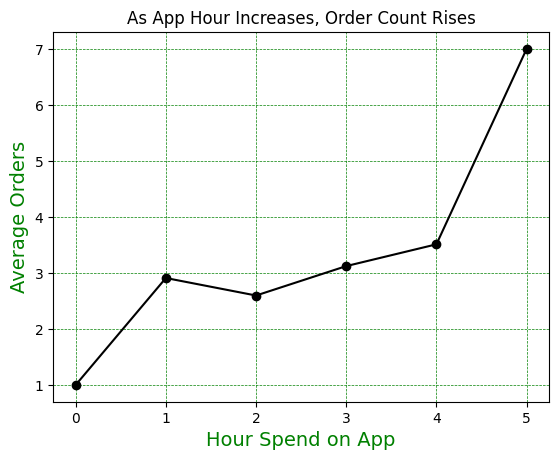

In [87]:
df.groupby('HourSpendOnApp')['OrderCount'].mean().plot(kind='line',marker='o', color = 'k')
plt.title('As App Hour Increases, Order Count Rises')
plt.ylabel('Average Orders', fontdict={'fontsize':14, 'color': 'green'})
plt.xlabel('Hour Spend on App', fontdict={'fontsize':14, 'color': 'green'})
plt.grid(color = 'green', linestyle = '--', linewidth = 0.5)
plt.show()

# 16. Is there a relationship between preferred order category and churn rate?

In [88]:
df2.groupby(['PreferedOrderCat','Gender'])['Churn'].count()

PreferedOrderCat    Gender
Fashion             Female     354
                    Male       472
Grocery             Female     198
                    Male       212
Laptop & Accessory  Female     844
                    Male      1206
Mobile Phone        Female     764
                    Male      1316
Others              Female      86
                    Male       178
Name: Churn, dtype: int64

In [89]:
pd.crosstab(df['PreferedOrderCat'],df['Churn'],normalize='index')

Churn,0,1
PreferedOrderCat,,
Fashion,0.845036,0.154964
Grocery,0.951220,0.048780
Laptop & Accessory,0.897561,0.102439
Mobile Phone,0.725962,0.274038
Others,0.924242,0.075758


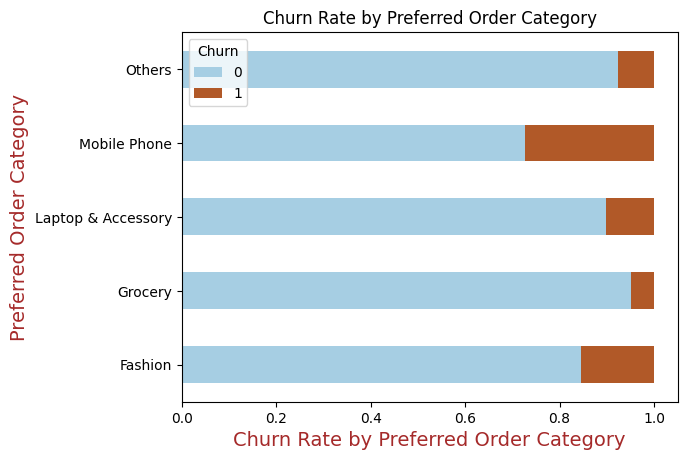

In [90]:
pd.crosstab(df['PreferedOrderCat'],df['Churn'],normalize='index').plot(kind='barh',stacked=True, colormap='Paired')
plt.title('Churn Rate by Preferred Order Category')
plt.xlabel('Churn Rate by Preferred Order Category', fontdict={'fontsize':14, 'color': 'brown'})
plt.ylabel('Preferred Order Category', fontdict={'fontsize':14, 'color': 'brown'})
plt.show()

# 17. Do customers who used more coupons have lower churn rates?

In [91]:
df2.groupby(['CouponUsed','Churn'])['CustomerID'].count()

CouponUsed  Churn
0.0         0         844
            1         186
1.0         0        1727
            1         378
2.0         0        1061
            1         222
3.0         0         281
            1          46
4.0         0         167
            1          30
5.0         0         106
            1          23
6.0         0          90
            1          18
7.0         0          71
            1          18
8.0         0          33
            1           9
9.0         0          11
            1           2
10.0        0          11
            1           3
11.0        0          10
            1           2
12.0        0           8
            1           1
13.0        0           8
14.0        0           5
15.0        1           1
16.0        0           1
            1           1
Name: CustomerID, dtype: int64

In [92]:
df2.groupby(['CouponUsed'])['Churn'].value_counts()

CouponUsed  Churn
0.0         0         844
            1         186
1.0         0        1727
            1         378
2.0         0        1061
            1         222
3.0         0         281
            1          46
4.0         0         167
            1          30
5.0         0         106
            1          23
6.0         0          90
            1          18
7.0         0          71
            1          18
8.0         0          33
            1           9
9.0         0          11
            1           2
10.0        0          11
            1           3
11.0        0          10
            1           2
12.0        0           8
            1           1
13.0        0           8
14.0        0           5
15.0        1           1
16.0        0           1
            1           1
Name: count, dtype: int64

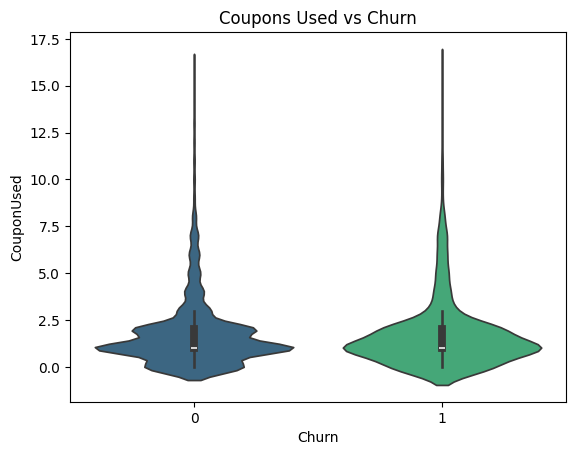

In [93]:
sns.violinplot(data=df, x="Churn", y="CouponUsed", palette='viridis')
plt.title("Coupons Used vs Churn")
plt.show()


* **The Shape (Density):** Both violins have a very wide "base" at the 1 and 2 coupon marks. This means the vast majority of your customers—regardless of whether they churn or not—only use a couple of coupons.

* **The "Tail" (Outliers):** You can see long, thin lines stretching upward to 15+ coupons. These are your "extreme couponers."

* **The Median (White Dot):** The white dot in the center of both violins is at almost the exact same height (around 1).

**"Coupon usage is NOT a primary driver for retention in this dataset."**

# 18. Is there a connection between satisfaction score and number of orders in the past month?

In [94]:
df2.groupby(['SatisfactionScore'])['OrderCount'].count()

,OrderCount
SatisfactionScore,
1,1120
2,558
3,1618
4,1020
5,1056


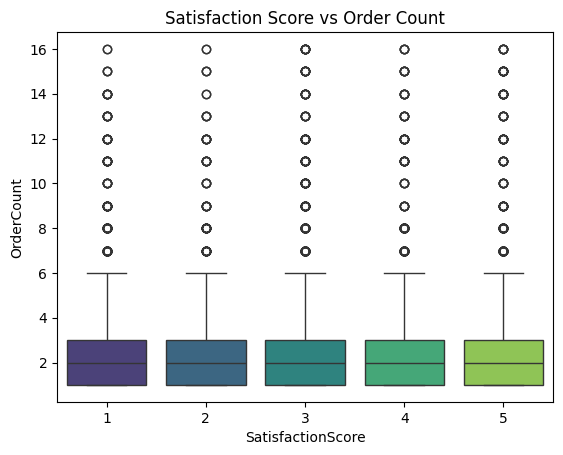

In [95]:
sns.boxplot(data=df, x='SatisfactionScore',y='OrderCount', palette='viridis')
plt.title('Satisfaction Score vs Order Count')
plt.show()

In [96]:
fig = px.box(df2, y="OrderCount", x='SatisfactionScore', color="SatisfactionScore", title="<b>"+'SatisfactionScore Vs OrderCount',
             boxmode="overlay", points='all')

fig.update_layout(hovermode='x',title_font_size=30,
                  title_font_color="black",
                  template="plotly",
                  hoverlabel_font_size=20,
                  title_x=0.5,
                  xaxis_title='SatisfactionScore',
                  yaxis_title='OrderCount'
)

# This section ensures the X-axis stays in 1, 2, 3, 4, 5 order
fig.update_xaxes(
    title_text='<b>Satisfaction Score</b>',
    categoryorder='array',
    categoryarray=['1', '2', '3', '4', '5']
)

fig.update_yaxes(title_text='<b>Order Count</b>')

fig.show()